# test Model B implementation

In [1]:
import numpy as np 
# --- provabgs ---
from provabgs import infer as Infer
from provabgs import models as Models

In [2]:
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rcParams['text.usetex'] = True
#mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [3]:
# SPS parameter priors
prior_sps = Infer.load_priors([
    Infer.UniformPrior(7., 12.5, label='sed'),
    Infer.FlatDirichletPrior(4, label='sed'),           # flat dirichilet priors
    Infer.UniformPrior(0., 1., label='sed'),            # burst fraction
    Infer.UniformPrior(1e-2, 13.27, label='sed'),       # tburst
    Infer.LogUniformPrior(4.5e-5, 1.5e-2, label='sed'), # log uniform priors on ZH coeff
    Infer.LogUniformPrior(4.5e-5, 1.5e-2, label='sed'), # log uniform priors on ZH coeff
    Infer.UniformPrior(0., 3., label='sed'),            # uniform priors on dust1
    Infer.UniformPrior(0., 3., label='sed'),            # uniform priors on dust2
    Infer.UniformPrior(-2., 1., label='sed'),            # uniform priors on dust_index
    Infer.UniformPrior(0.1, 15., label='sed'),          # uniform priors on Umin
    Infer.UniformPrior(0.0, 0.15, label='sed'),          # uniform priors on gamma_e
    Infer.UniformPrior(0.1, 0.7, label='sed') # uniform prior on Q_PAH
])

In [4]:
m_sps = Models.NMF_NDE(burst=True, emulator=False)

input parameters : logmstar, beta1_sfh, beta2_sfh, beta3_sfh, beta4_sfh, fburst, tburst, gamma1_zh, gamma2_zh, dust1, dust2, dust_index, dust_umin, dust_gammae, dust_qpah


In [5]:
m_sps._ssp_initiate()

In [6]:
theta_sps  = prior_sps.transform(prior_sps.sample())
redshift   = 1e-3

In [7]:
theta_fid = theta_sps.copy()
theta_fid[10] = 3.
theta_fid[12] = 10.
theta_fid[13] = 0.1
theta_fid[14] = 3.0

In [8]:
w, f = m_sps.sed(theta_fid, redshift)

(0.2, 20.0)

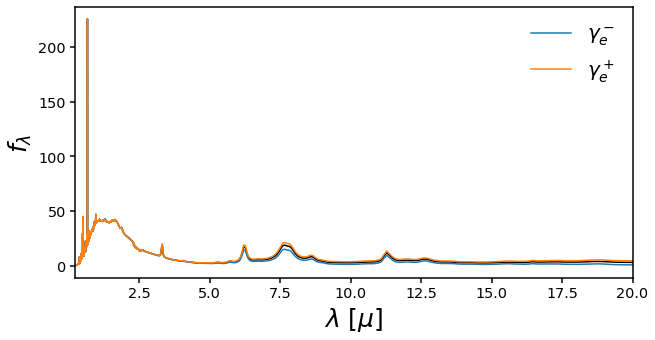

In [9]:
fig = plt.figure(figsize=(10,5))
sub = fig.add_subplot(111)
sub.plot(w/1e4, f, c='k')

_theta = theta_fid.copy()
_theta[-2] = 0.0
w0, f0 = m_sps.sed(_theta, redshift)
sub.plot(w0/1e4, f0, c='C0', label='$\gamma_e^-$')

_theta = theta_fid.copy()
_theta[-2] = 0.5
w0, f0 = m_sps.sed(_theta, redshift)
sub.plot(w0/1e4, f0, c='C1', label='$\gamma_e^+$')

sub.legend(loc='upper right', fontsize=20)
sub.set_ylabel('$f_\lambda$', fontsize=25)
sub.set_xlabel('$\lambda$ [$\mu$]', fontsize=25)
sub.set_xlim(0.2, 20)

(0.2, 20.0)

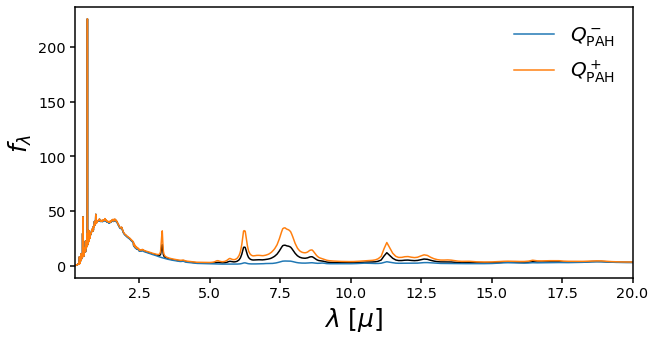

In [10]:
fig = plt.figure(figsize=(10,5))
sub = fig.add_subplot(111)
sub.plot(w/1e4, f, c='k')

_theta = theta_fid.copy()
_theta[-1] = 0.0
w0, f0 = m_sps.sed(_theta, redshift)
sub.plot(w0/1e4, f0, c='C0', label=r'$Q_{\rm PAH}^-$')

_theta = theta_fid.copy()
_theta[-1] = 6.0
w0, f0 = m_sps.sed(_theta, redshift)
sub.plot(w0/1e4, f0, c='C1', label=r'$Q_{\rm PAH}^+$')


sub.legend(loc='upper right', fontsize=20)
sub.set_ylabel('$f_\lambda$', fontsize=25)
sub.set_xlabel('$\lambda$ [$\mu$]', fontsize=25)
sub.set_xlim(0.2, 20)